In [2]:
# ==========================================================
# CELL 1 : IMPORT LIBRARIES
# ==========================================================

import gradio as gr

import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from PIL import Image

from tensorflow.keras.models import load_model

In [17]:
# ==========================================================
# CELL 2 : LOAD MODEL
# ==========================================================

MODEL_PATH = r"D:\multidieseases\EfficientNetV2_BCE_FineTuned.keras"

model = load_model(MODEL_PATH)

print("✅ Model Loaded Successfully")

model.summary()

✅ Model Loaded Successfully


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 9,241,660 (35.25 MB)

 Trainable params: 1,495,406 (5.70 MB)

 Non-trainable params: 4,755,440 (18.14 MB)

 Optimizer params: 2,990,814 (11.41 MB)

In [27]:
# ==========================================================
# CELL 3 : CONFIGURATION
# ==========================================================

selected_diseases = [

    "DR",
    "ARMD",
    "MH",
    "DN",
    "MYA",
    "BRVO",
    "TSLN",
    "LS",
    "CSR",
    "ODC",
    "ODP",
    "ODE",
    "RS",
    "CRS"

]

# Last convolution layer of EfficientNetV2B0
last_conv_layer_name = "top_conv"

# Prediction threshold
THRESHOLD = 0.5

print("✅ Number of diseases :", len(selected_diseases))
print("✅ Grad-CAM Layer :", last_conv_layer_name)

✅ Number of diseases : 14
✅ Grad-CAM Layer : top_conv


In [28]:
# ==========================================================
# CELL 4 : GRAD-CAM FUNCTION
# ==========================================================

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index):

    # Model that outputs:
    # 1. Feature maps from last conv layer
    # 2. Final predictions
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    # Compute gradients
    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        class_channel = predictions[:, pred_index]

    # Gradient of prediction w.r.t feature maps
    grads = tape.gradient(class_channel, conv_outputs)

    # Global Average Pooling on gradients
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    # Remove batch dimension
    conv_outputs = conv_outputs[0]

    # Weight feature maps by importance
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    # Apply ReLU
    heatmap = tf.maximum(heatmap, 0)

    # Normalize safely (avoid divide-by-zero)
    max_val = tf.reduce_max(heatmap)

    if max_val > 0:
        heatmap = heatmap / max_val

    heatmap = heatmap.numpy()

    return heatmap

In [29]:
# Test Grad-CAM

test_img = np.random.rand(1,224,224,3).astype(np.float32)

heatmap = make_gradcam_heatmap(
    test_img,
    model,
    last_conv_layer_name,
    0
)

print("Heatmap Shape:", heatmap.shape)
print("Min:", heatmap.min())
print("Max:", heatmap.max())

Heatmap Shape: (7, 7)
Min: 0.22218786
Max: 1.0


In [41]:
# ==========================================================
# CELL 5 : PREDICTION FUNCTION
# ==========================================================

def predict_retinal(image):

    # -----------------------------
    # Convert PIL -> RGB
    # -----------------------------
    image = image.convert("RGB")
    image = image.resize((224,224))

    original = np.array(image, dtype=np.uint8)

    input_image = np.expand_dims(
        original.astype(np.float32),
        axis=0
    )

    # -----------------------------
    # Prediction
    # -----------------------------
    predictions = model.predict(
        input_image,
        verbose=0
    )[0]

    # Dictionary for Gradio Label
    prediction_dict = {
        disease: float(prob)
        for disease, prob in zip(selected_diseases, predictions)
    }

    # -----------------------------
    # Diagnosis Summary
    # -----------------------------
    detected = []

    for disease, prob in zip(selected_diseases, predictions):

        if prob >= THRESHOLD:

            detected.append(
                f"✔ {disease} ({prob*100:.2f}%)"
            )

    if len(detected) == 0:
        summary = "Normal Retina"
    else:
        summary = "\n".join(detected)

    # -----------------------------
    # Disease for Grad-CAM
    # -----------------------------
    valid = np.where(predictions >= THRESHOLD)[0]

    if len(valid) > 0:

        pred_index = valid[
            np.argmax(predictions[valid])
        ]

    else:

        pred_index = np.argmax(predictions)

    # -----------------------------
    # Generate Heatmap
    # -----------------------------
      # -----------------------------
    # Generate Grad-CAM Heatmap
# -----------------------------
    heatmap = make_gradcam_heatmap(
        input_image,
        model,
        last_conv_layer_name,
        pred_index
    )

   # Resize to image size
    heatmap = cv2.resize(
        heatmap,
        (224, 224),
        interpolation=cv2.INTER_CUBIC
    )

   # Stretch contrast
    heatmap = cv2.normalize(
        heatmap,
        None,
        alpha=0,
        beta=255,
        norm_type=cv2.NORM_MINMAX
    )

    heatmap = heatmap.astype(np.uint8)

    # Apply colormap
    heatmap = cv2.applyColorMap(
        heatmap,
        cv2.COLORMAP_JET
    )

# Convert BGR → RGB
    heatmap = cv2.cvtColor(
        heatmap,
        cv2.COLOR_BGR2RGB
    )

    # -----------------------------
    # Overlay
    # -----------------------------
    overlay = cv2.addWeighted(
        original,
        0.6,
        heatmap,
        0.4,
        0
    )

    return (
        prediction_dict,
        summary,
        heatmap,
        overlay
    )

In [ ]:
from PIL import Image

img = Image.open(r"D:\multidieseases\Test_Set\Test_Set\Test\1.png")

result = predict_retinal(img)

print(type(result))
print(len(result))

<class 'tuple'>
4


In [32]:
result[0]

{'DR': 0.4979230463504791,
 'ARMD': 0.39702531695365906,
 'MH': 0.3033270537853241,
 'DN': 0.26539361476898193,
 'MYA': 0.399253785610199,
 'BRVO': 0.4086638391017914,
 'TSLN': 0.3635510504245758,
 'LS': 0.3649112284183502,
 'CSR': 0.2192218154668808,
 'ODC': 0.25150054693222046,
 'ODP': 0.26274415850639343,
 'ODE': 0.336367666721344,
 'RS': 0.25260213017463684,
 'CRS': 0.270843505859375}

In [33]:
result[1]

'Normal Retina'

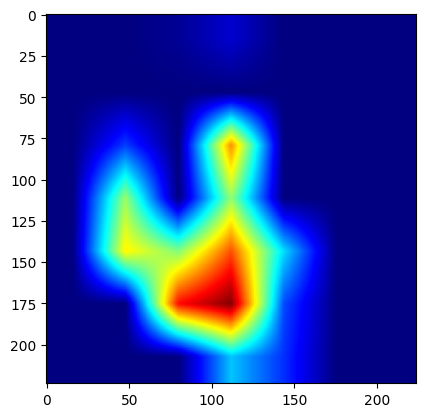

In [42]:
plt.imshow(result[2])
plt.show()

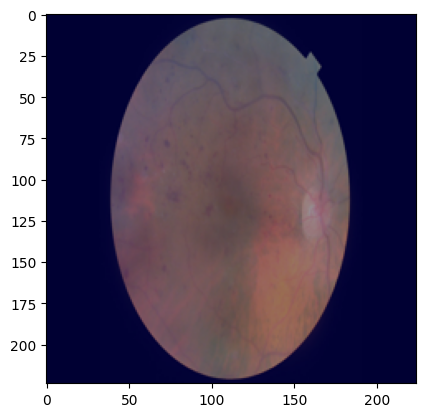

In [34]:
plt.imshow(result[3])
plt.show()

Summary:
✔ MYA (69.24%)
✔ TSLN (53.25%)

Probabilities:
DR    : 0.410
ARMD  : 0.415
MH    : 0.277
DN    : 0.248
MYA   : 0.692
BRVO  : 0.279
TSLN  : 0.532
LS    : 0.316
CSR   : 0.194
ODC   : 0.354
ODP   : 0.262
ODE   : 0.276
RS    : 0.231
CRS   : 0.201


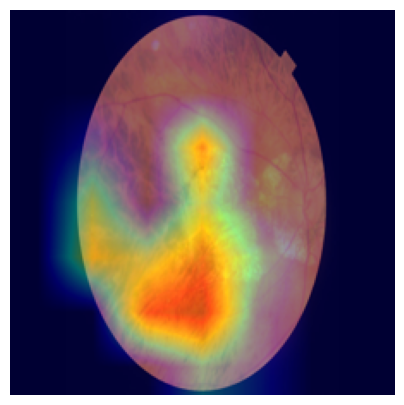

In [38]:
from PIL import Image

img = Image.open(r"D:\multidieseases\Test_Set\Test_Set\Test\110.png")

result = predict_retinal(img)

print("Summary:")
print(result[1])

print("\nProbabilities:")
for disease, prob in result[0].items():
    print(f"{disease:6s}: {prob:.3f}")

plt.figure(figsize=(5,5))
plt.imshow(result[3])   # Overlay image
plt.axis("off")
plt.show()

In [1]:
with gr.Blocks(theme=gr.themes.Soft()) as demo:

    gr.Markdown(
        """
        # 👁️ Retinal Disease Detection using EfficientNetV2B0

        Upload a retinal fundus image to detect diseases and visualize the model's attention using Grad-CAM.
        """
    )

    with gr.Row():

        input_image = gr.Image(
            type="pil",
            label="Upload Fundus Image"
        )

        with gr.Column():

            # prediction = gr.Label(
            #    label="Disease Probabilities"
            #)

            summary = gr.Textbox(
                label="Diagnosis Summary"
            )

    with gr.Row():

        heatmap = gr.Image(
            label="Grad-CAM Heatmap"
        )

        overlay = gr.Image(
            label="Overlay Image"
        )

    predict_button = gr.Button(
        "🔍 Predict"
    )

    predict_button.click(

        fn=predict_retinal,

        inputs=input_image,

        outputs=[
            prediction,
            summary,
            heatmap,
            overlay
        ]

    )


NameError: name 'gr' is not defined

In [45]:
demo.launch(
    debug=True,
    show_error=True
)

* Running on local URL:  http://127.0.0.1:7865
* To create a public link, set `share=True` in `launch()`.


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Keyboard interruption in main thread... closing server.
